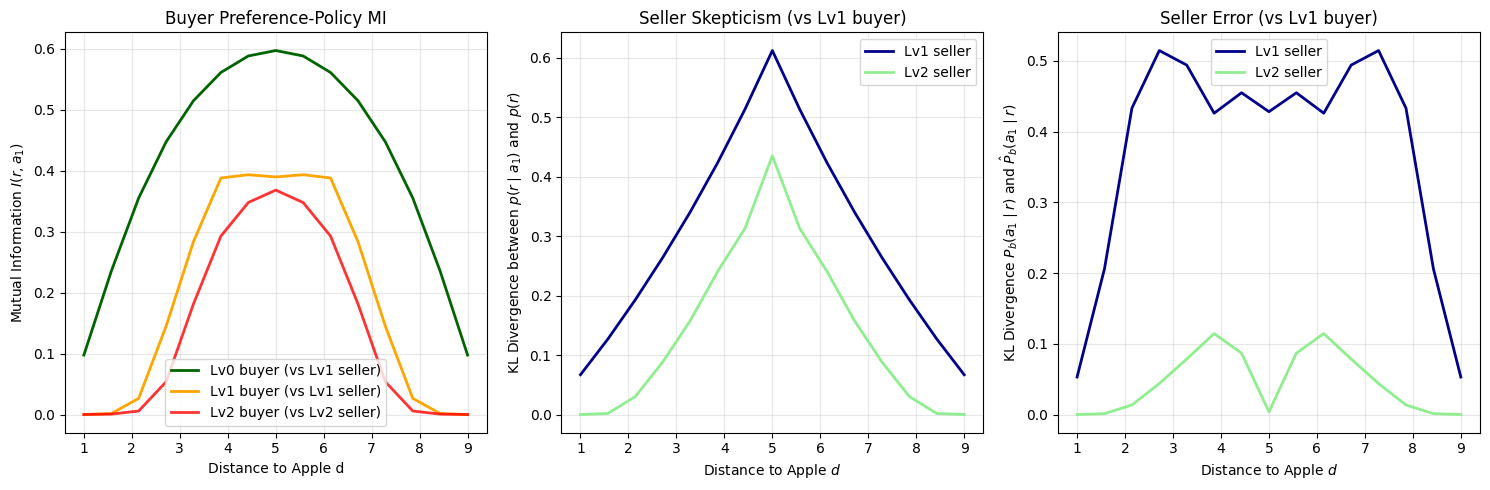


=== 요약 통계 ===
L0B_vs_L1S:
  평균 I(r, a₁): 0.413
  평균 D_KL(p(r|a₁)||p(r)): 0.298
  평균 Seller Error: 0.000
L1B_vs_L1S:
  평균 I(r, a₁): 0.191
  평균 D_KL(p(r|a₁)||p(r)): 0.298
  평균 Seller Error: 0.373
L1B_vs_L2S:
  평균 I(r, a₁): 0.191
  평균 D_KL(p(r|a₁)||p(r)): 0.140
  평균 Seller Error: 0.045
L2B_vs_L1S:
  평균 I(r, a₁): 0.142
  평균 D_KL(p(r|a₁)||p(r)): 0.298
  평균 Seller Error: 0.045
L2B_vs_L2S:
  평균 I(r, a₁): 0.142
  평균 D_KL(p(r|a₁)||p(r)): 0.140
  평균 Seller Error: 0.045


In [8]:
import os
os.chdir("/home/youngjins/project/belief_trading/")

import json
import numpy as np
import matplotlib.pyplot as plt

# 결과 파일 로드
results_path = "./results/exp2/20250610_2056/simulation_results.json"
with open(results_path, "r") as f:
    results_serializable = json.load(f)

# numpy 배열로 변환
results = {}
for key, value in results_serializable.items():
    results[key] = {
        "mutual_info_I_r_a1": np.array(value["mutual_info_I_r_a1"]),
        "belief_updates_D_KL": np.array(value["belief_updates_D_KL"]),
        "policies_P": [np.array(policy) for policy in value["policies_P"]],
        "seller_error": np.array(value["seller_error"])
    }

# distance vector 생성 (결과 데이터 길이에 맞춤)
n_samples = len(results[list(results.keys())[0]]["mutual_info_I_r_a1"])
candidate_vector_d = np.linspace(1, 9, n_samples)

# 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Figure 3F: Mutual Information I(r, a₁)
ax = axes[0]
ax.plot(
    candidate_vector_d,
    results["L0B_vs_L1S"]["mutual_info_I_r_a1"],
    label="Lv0 buyer (vs Lv1 seller)",
    linewidth=2,
    color="darkgreen",
)
ax.plot(
    candidate_vector_d,
    results["L1B_vs_L1S"]["mutual_info_I_r_a1"],
    label="Lv1 buyer (vs Lv1 seller)",
    linewidth=2,
    color="orange",
)
# ax.plot(
#     candidate_vector_d,
#     results["L1B_vs_L2S"]["mutual_info_I_r_a1"],
#     label="Lv1 buyer (vs Lv2 seller)",
#     linewidth=2,
#     color="lightgreen",
# )
# ax.plot(
#     candidate_vector_d,
#     results["L2B_vs_L1S"]["mutual_info_I_r_a1"],
#     label="Lv2 buyer (vs Lv1 seller)",
#     linewidth=2,
#     color="lightblue",
# )
ax.plot(
    candidate_vector_d,
    results["L2B_vs_L2S"]["mutual_info_I_r_a1"],
    label="Lv2 buyer (vs Lv2 seller)",
    linewidth=2,
    alpha=0.8,
    color="red",
)
ax.set_xlabel("Distance to Apple d")
ax.set_ylabel("Mutual Information $I(r, a_1)$")
ax.set_title("Buyer Preference-Policy MI")
ax.legend()
ax.grid(True, alpha=0.3)

# Figure 3G: Seller Skepticism
ax = axes[1]
# ax.plot(
#     candidate_vector_d,
#     results["L0B_vs_L1S"]["belief_updates_D_KL"],
#     label="Lv0 seller (vs Lv0 buyer)",
#     linewidth=2,
#     color="darkblue",
# )
ax.plot(
    candidate_vector_d,
    results["L1B_vs_L1S"]["belief_updates_D_KL"],
    label="Lv1 seller",
    linewidth=2,
    color="darkblue",
)
ax.plot(
    candidate_vector_d,
    results["L1B_vs_L2S"]["belief_updates_D_KL"],
    label="Lv2 seller",
    linewidth=2,
    color="lightgreen",
)
ax.set_xlabel("Distance to Apple $d$")
ax.set_ylabel("KL Divergence between $p(r \mid a_1)$ and $p(r)$")
ax.set_title("Seller Skepticism (vs Lv1 buyer)")
ax.legend()
ax.grid(True, alpha=0.3)

# Figure 3H: Seller Error
ax = axes[2]
ax.plot(
    candidate_vector_d,
    results["L1B_vs_L1S"]["seller_error"],
    label="Lv1 seller",
    linewidth=2,
    color="darkblue",
)
# ax.plot(
#     candidate_vector_d,
#     results["L1B_vs_L2S"]["seller_error"],
#     label="Lv2 seller error (vs Lv1 buyer)",
#     linewidth=2,
#     color="lightgreen",
# )
ax.plot(
    candidate_vector_d,
    results["L1B_vs_L2S"]["seller_error"],
    label="Lv2 seller",
    linewidth=2,
    color="lightgreen",
)
ax.set_xlabel("Distance to Apple $d$")
ax.set_ylabel("KL Divergence $P_b(a_1 \mid r)$ and $\hat{P}_b(a_1 \mid r)$")
ax.set_title("Seller Error (vs Lv1 buyer)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 요약 통계
print("\n=== 요약 통계 ===")
for key in results.keys():
    mi_I_r_a1_avg = np.mean(results[key]["mutual_info_I_r_a1"])
    belief_D_KL_avg = np.mean(results[key]["belief_updates_D_KL"])
    seller_error_avg = np.mean(results[key]["seller_error"])
    print(f"{key}:")
    print(f"  평균 I(r, a₁): {mi_I_r_a1_avg:.3f}")
    print(f"  평균 D_KL(p(r|a₁)||p(r)): {belief_D_KL_avg:.3f}")
    print(f"  평균 Seller Error: {seller_error_avg:.3f}")
